# Diagnostics! 

#### Importing functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../../"))    # Calling the HorizonFinder.py source code from src
from src.source import axisym

#### Data produced & Plots

In [2]:
# Load data
data = pd.read_csv("./data/horizon_common.csv")
theta = data["theta"].values
h = data["h"].values

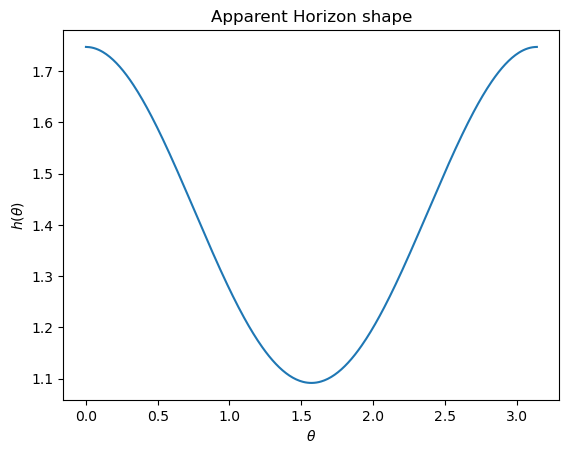

In [3]:
# Plot the surface profile
plt.plot(theta, h)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$h(\theta)$")
plt.title("Apparent Horizon shape")
plt.show()

#### 

In [7]:
# ----- Parameters ----
M1  = 1.0
M2  = 1.0
sep = 0.5                   # separation factor (critical = 0.767)
z0  = sep*(M1 + M2)         # distance from origin
phi = 0


# Spatial metric gamma_ij in spherical coordinates (no phi dependance)
def gammaij(r, theta):
    epsilon = 1e-12
    r = max(r, epsilon)
    x = r*np.sin(theta)*np.cos(phi)
    y = r*np.sin(theta)*np.sin(phi)
    z = r*np.cos(theta)
    
    r1 = np.sqrt(x**2 + y**2 + (z + z0)**2)
    r2 = np.sqrt(x**2 + y**2 + (z - z0)**2)
    r1 = max(r1, epsilon)
    r2 = max(r2, epsilon)
    
    psi = 1 + M1/(2*r1) + M2/(2*r2)
    return np.array([
        [psi**4, 0, 0],
        [0, psi**4 * r**2, 0],
        [0, 0, psi**4 * r**2 * np.sin(theta)**2]
    ])


# Extrinsic curvature (zero in time-symmetric slice)
def Kij(r, theta=None, phi=None):
    return np.zeros((3,3))

#   Create solver instance
solver = axisym(gammaij, Kij)


Solving for horizon ...


In [11]:
# Suppose your class instance is called `solver`
Residual = solver.Horizon(h, theta, dtheta=theta[1] - theta[0])
print(Residual)

[ 4.68669979e-07 -1.92914895e-09  8.10178882e-10 -1.46146544e-09
  1.96468491e-09 -4.44572382e-10 -4.88082786e-11  6.50106132e-11
 -2.38456012e-10 -6.08805565e-10  2.85711008e-09 -9.14803153e-10
 -5.10577240e-11  4.14912518e-10 -3.62653629e-10  2.83614451e-11
 -8.69303726e-11  4.29846145e-10 -1.83473083e-09  7.50167380e-10
  1.87569543e-10 -1.53449961e-10 -9.34273492e-11  7.98776212e-10
  3.37250033e-10  5.79665871e-10  1.38253645e-09 -4.30893488e-10
  5.92994029e-10  2.13851006e-10 -1.74134626e-09 -5.51909435e-10
  7.83780235e-10 -7.08691605e-10 -4.26771229e-10 -8.88474572e-10
 -9.04191721e-11 -6.45214299e-10 -1.21944232e-10  8.58202398e-11
 -9.18362608e-12  3.37066486e-12 -5.43469658e-10 -5.15416598e-10
  4.04739131e-10 -8.86027529e-10  4.57669735e-10 -1.10465259e-09
  2.70578837e-10 -4.60358474e-10 -1.10730747e-09  1.07867437e-10
  5.11525100e-10  1.23805505e-09  2.81405899e-10  1.59477875e-10
  6.94576119e-10 -1.46388096e-09  8.15010837e-11  9.97624372e-10
 -4.28127311e-10  5.98921

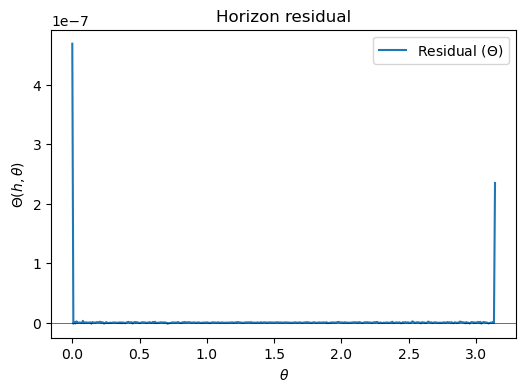

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(theta, Residual, label="Residual ($\Theta$)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\Theta(h,\theta)$")
plt.title("Horizon residual")
plt.axhline(0, color='k', lw=0.4)
plt.legend()
plt.show()